# 🧹 Data Cleaning & Sales Analysis
## Brazilian E-Commerce — Olist Dataset
**Author:** Nayla 

## 1. Library & Dependencies

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [19]:
orders    = pd.read_csv('../data/raw/olist_orders_dataset.csv')
items     = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
payments  = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
products  = pd.read_csv('../data/raw/olist_products_dataset.csv')

## 3. Data Filtering
Memfilter hanya pesanan dengan status **delivered** karena transaksinya sudah selesai dan valid untuk dianalisis.

In [20]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

date_cols = ['order_purchase_timestamp', 
             'order_approved_at',
             'order_delivered_customer_date']
for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

print(f"Order delivered: {len(orders_clean):,} dari {len(orders):,} total")

Order delivered: 96,478 dari 99,441 total


## 4. Data Merging
Menggabungkan 5 tabel utama menjadi satu dataframe terpadu untuk memudahkan analisis selanjutnya.

In [21]:
df = orders_clean.merge(items, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(payments[['order_id','payment_value']]
              .groupby('order_id').sum().reset_index(), 
              on='order_id', how='left')
df = df.merge(products[['product_id','product_category_name']], 
              on='product_id', how='left')

print(f"Shape akhir: {df.shape}")
df.head(3)

Shape akhir: (110197, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,automotivo


## 5. Save Cleaned Data
Menyimpan data bersih ke folder `data/processed/` untuk digunakan pada tahap analisis berikutnya.

In [22]:
df.to_csv('../data/processed/olist_clean.csv', index=False)
print("Data bersih tersimpan!")

Data bersih tersimpan!


## 6. Top 10 Kategori Produk berdasarkan Revenue
Menganalisis kategori produk yang paling berkontribusi terhadap total revenue perusahaan.

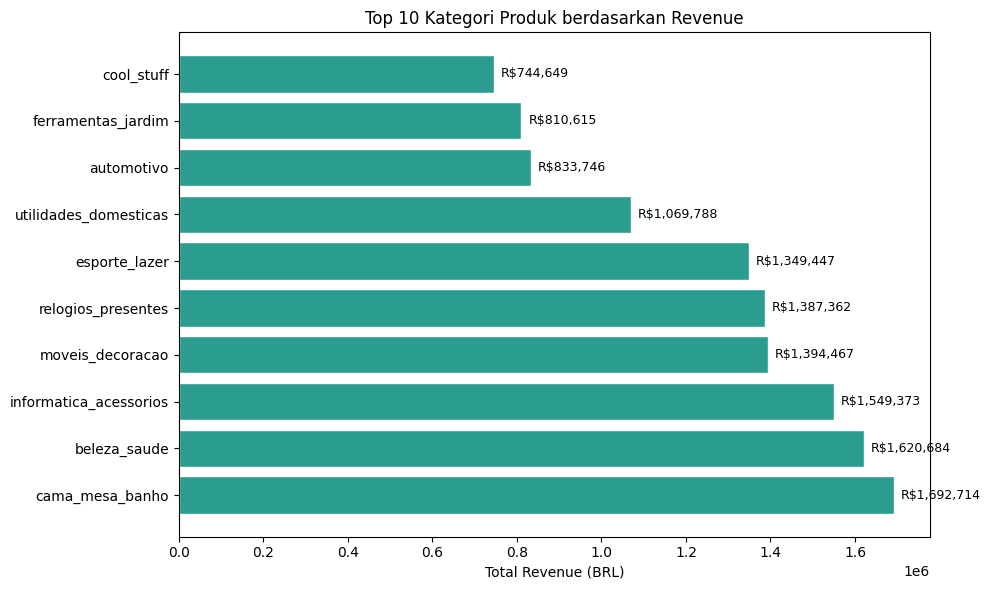

In [23]:
df = pd.read_csv('../data/processed/olist_clean.csv')

cat_revenue = df.groupby('product_category_name').agg(
    total_revenue=('payment_value', 'sum'),
    total_orders=('order_id', 'nunique')
).sort_values('total_revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_revenue.index, cat_revenue['total_revenue'], 
               color='#2a9d8f', edgecolor='white')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_title('Top 10 Kategori Produk berdasarkan Revenue')
ax.bar_label(bars, fmt='R${:,.0f}', padding=5, fontsize=9)
plt.tight_layout()
plt.savefig('../output/charts/02_top_categories.png', dpi=150)
plt.show()

## 7. Tren Revenue Bulanan
Melihat pola pertumbuhan revenue dari waktu ke waktu untuk mengidentifikasi seasonal pattern dan tren bisnis.

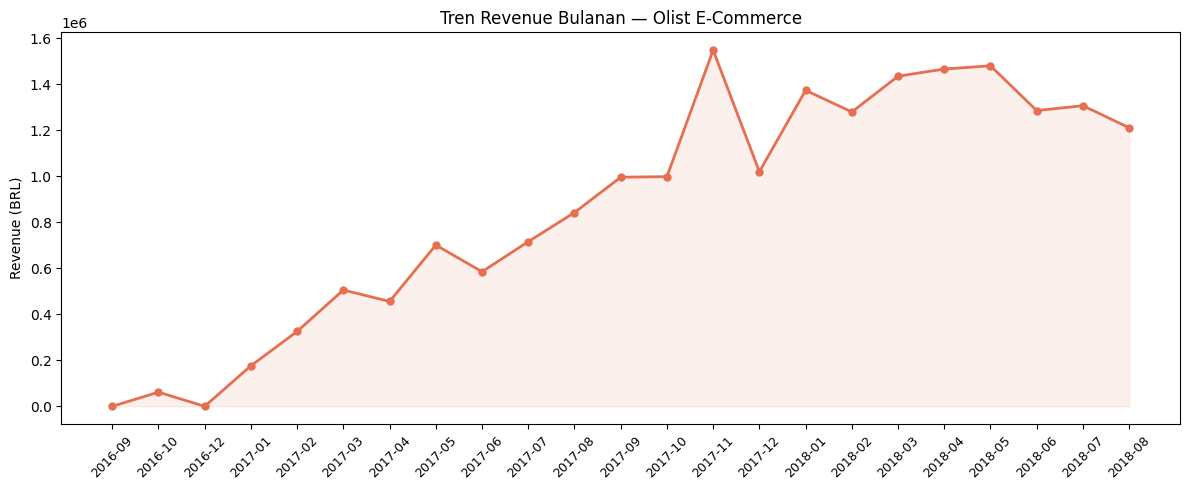

In [24]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_rev = df.groupby('year_month')['payment_value'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_rev.index.astype(str), monthly_rev.values, 
         marker='o', color='#e76f51', linewidth=2, markersize=5)
plt.fill_between(range(len(monthly_rev)), monthly_rev.values, 
                 alpha=0.1, color='#e76f51')
plt.xticks(rotation=45, fontsize=9)
plt.title('Tren Revenue Bulanan — Olist E-Commerce')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('../output/charts/03_monthly_revenue.png', dpi=150)
plt.show()